In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.mock_maker import MakeMock

from source_code.likelihood import LSSlike

from cobaya.run import run

from copy import deepcopy

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c',

yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

# Settings

## Options

In [2]:
#mock_path   = 'mock_data/new_LSS_GW_ellcut_LCDM'
#observables = ['GC','WL','GWC','GWWL']
mock_path   = 'mock_data/new_LSS_LCDM'
observables = ['GC','WL']
camb_path   = '/home/Matteo/Codes/GW-MGCAMB'


SNR_threshold = 1

bin_to_plot = [1,3,6]

covmats_ells_toplot = [5,10]

#We will run a grid chi2 test on this parameter
run_grid_test = False
test_parameter = {'name': 'logA',
                  'variation': 0.1,
                  'latex': r'$\log{10^{10}A_s}$',
                  'Ngrid': 10,
                  'noiseless_like': True}

## Specifications

In [3]:
gwspecs  = {'Nbins_GW': 6,
            'N_gw': int(1.e6),
            'sigma_eps_gw': 0.01,
            'fsky': 0.35,
            'scale_cut': {'method': 'ell_cut', 'value': 200}}

# Fiducial

In [4]:
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.002918,
            'a4': -0.0006784,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            #'tau': 0.05,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            #MG params
            'mu0': 0.,
            'sigma0': 0.,
            'MG_flag': 0,#1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

print(np.exp(fiducial['logA'])*1.e-10)

2.126048105729501e-09


# Running mock maker

In [5]:
mock = MakeMock(gwspecs,observables,camb_path,fiducial,test_parameter)


Computing fiducial observables...
...done in 38.19 s


In [6]:
print(mock.mock_data.keys())

dict_keys(['noiseless', 'noisy', 'covmat_dict', 'distributions'])


# Showcase mock products

## Extracting noise from covariance diagonal (approximated)

In [7]:
error_df = pd.DataFrame({'ells': mock.fiducial_obs['ells']})
for j,obs1 in enumerate(mock.fishmodule.renamed_obs):
    for i,obs2 in enumerate(mock.fishmodule.renamed_obs):
        if i>=j:
            for bi in bin_to_plot:
                error = []
                for ell in mock.fiducial_obs['ells']:
                    ellcov = mock.mock_data['covmat_dict'][str(ell)]
                    error.append(np.sqrt(ellcov.at[obs1+str(bi)+'x'+obs2+str(bi),obs1+str(bi)+'x'+obs2+str(bi)]))
    
                error_df[obs1+str(bi)+'x'+obs2+str(bi)] = error

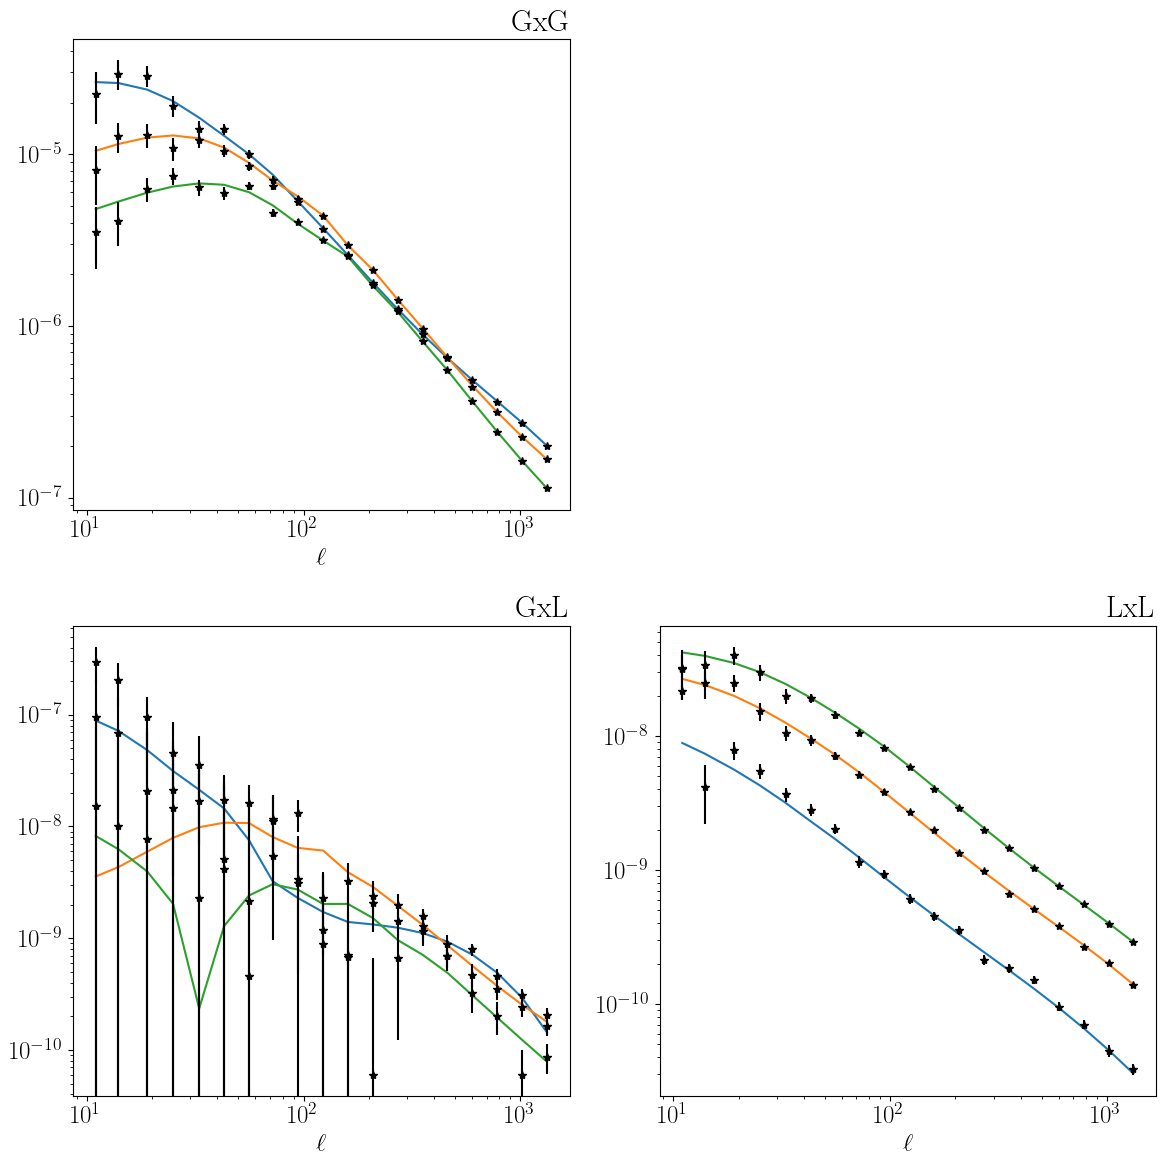

In [8]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(mock.fishmodule.renamed_obs),
                              nrows=len(mock.fishmodule.renamed_obs))
if len(mock.fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(mock.fishmodule.renamed_obs):
    for i,obs2 in enumerate(mock.fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:

            df = pd.melt(mock.mock_data['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                        for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)
#
            for bi in bin_to_plot:
                axes[i,j].errorbar(mock.mock_data['noisy']['ells'],abs(mock.mock_data['noisy'][obs1+str(bi)+'x'+obs2+str(bi)]),
                                  yerr=error_df[obs1+str(bi)+'x'+obs2+str(bi)],
                                  marker='*',ls='',color='black')

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            if obs1+obs2 != 'GL':
                axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

## Saving mock to file

In [9]:
if mock_path != '':
    mock.mock_data['noiseless'].to_csv(mock_path+'_Cls_noiseless.dat',sep='\t',header=True,float_format="%.10g")
    mock.mock_data['noisy'].to_csv(mock_path+'_Cls_noisy.dat',sep='\t',header=True,float_format="%.10g")
    np.save(mock_path+'_covmat.npy',mock.mock_data['covmat_dict'])
    np.save(mock_path+'_source_distribution.npy',mock.mock_data['distributions'])

## Mock properties

## SNR threshold

In [10]:
dfs = []
for ind,ell in enumerate(mock.fiducial_obs['ells']):
    ellcov = mock.mock_data['covmat_dict'][str(ell)]
    fidvec = mock.mock_data['noiseless'].iloc[ind][ellcov.columns]
    df = pd.DataFrame({'ells': ell},index=[0])
    for col in ellcov.columns:
        df[col] = abs(fidvec[col])/np.sqrt(ellcov.at[col,col])
    
    dfs.append(df)

SNR = pd.concat(dfs,ignore_index=True)
SNR_cut = SNR.copy()
for col in SNR_cut:
    if col != 'ells':
        if SNR_cut[col].max() <= SNR_threshold:
            SNR_cut = SNR_cut.drop([col], axis=1)

print(len(SNR.columns))
print(len(SNR_cut.columns))


211
169


In [11]:
#how to plot this?

# Mock testing

## Noiseless spectra check

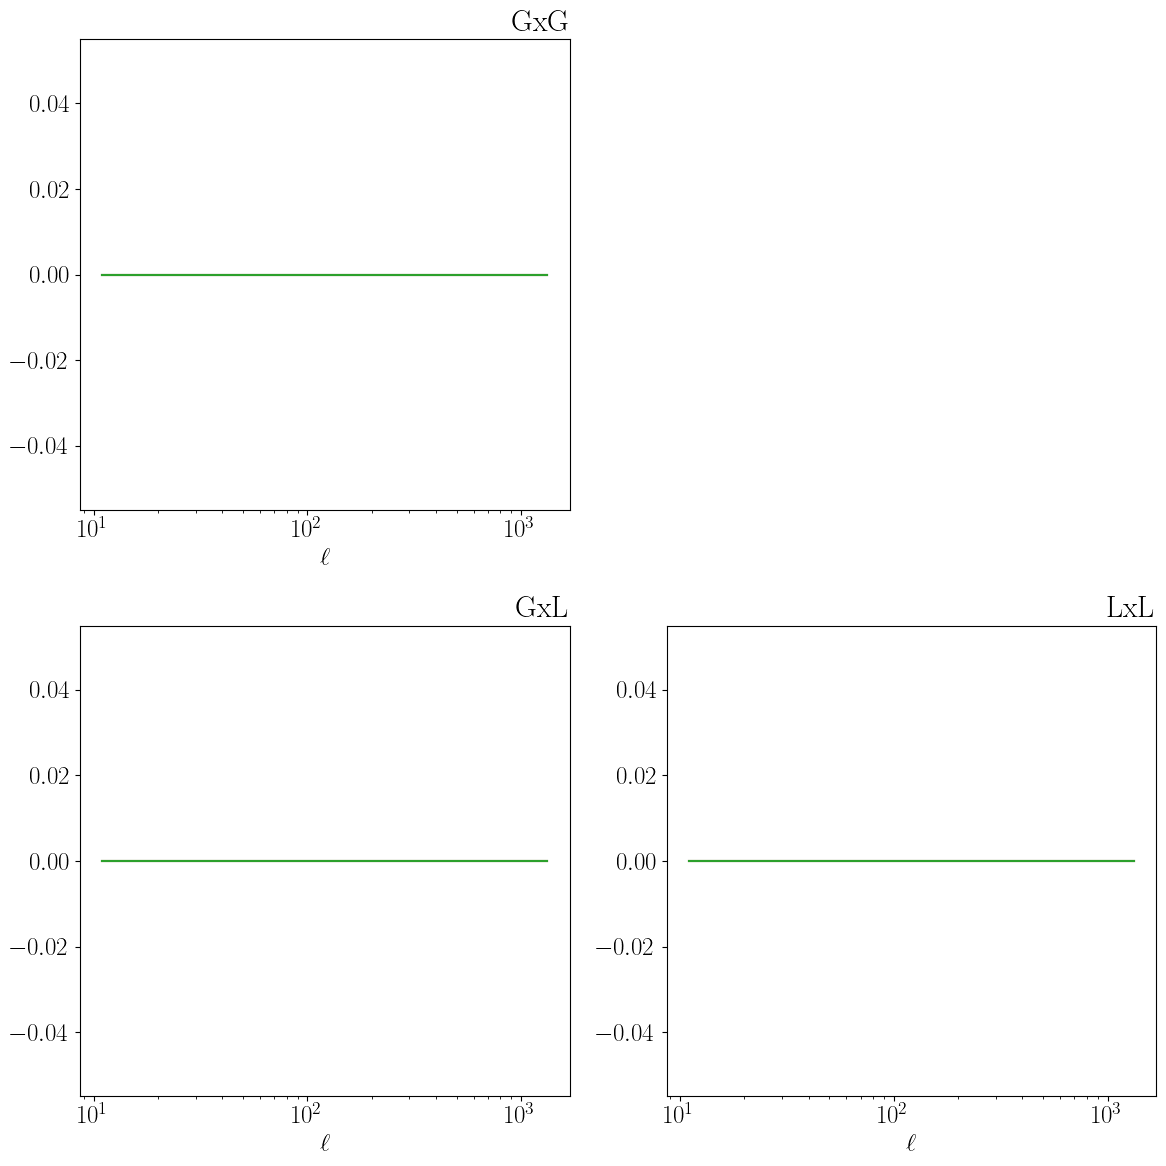

In [12]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(mock.fishmodule.renamed_obs),
                              nrows=len(mock.fishmodule.renamed_obs))
if len(mock.fishmodule.renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(mock.fishmodule.renamed_obs):
    for i,obs2 in enumerate(mock.fishmodule.renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df_fiducial = pd.melt(mock.fiducial_obs.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                       for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            #sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            df_noiseless = pd.melt(mock.mock_data['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                                  for bi in bin_to_plot],
                         value_name='value',var_name='Bin')

            df = df_fiducial.copy()
            df['value'] = abs(df_fiducial['value']-df_noiseless['value'])
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

## Covariance stability

### Eigenvalues

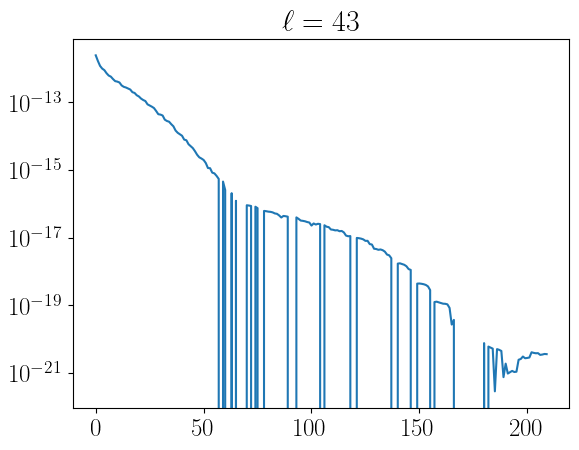

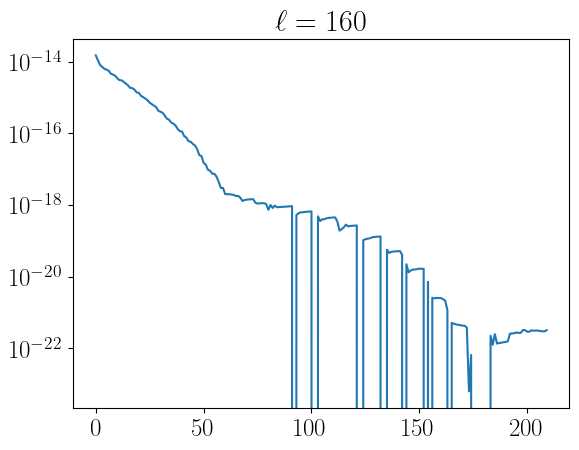

In [13]:
for ind,ell in enumerate(mock.fiducial_obs['ells']):
    if ind in covmats_ells_toplot:
        plt.figure()
        plt.title(r'$\ell={}$'.format(ell))
        plt.semilogy(np.linalg.eigvals(mock.mock_data['covmat_dict'][str(ell)]))

### Inversion

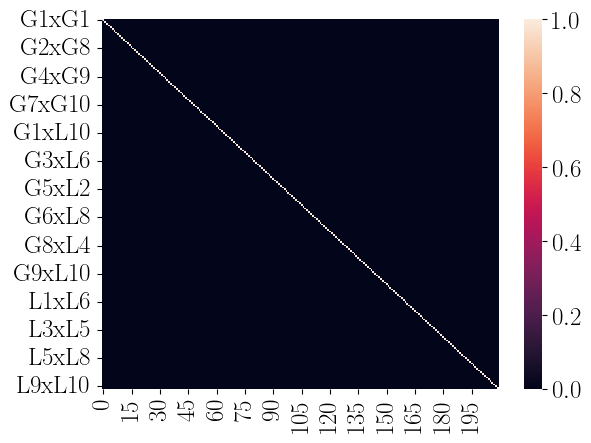

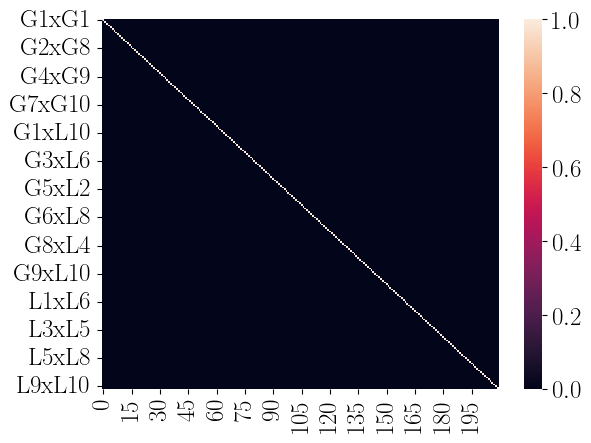

In [14]:
for ind,ell in enumerate(mock.fiducial_obs['ells']):
    if ind in covmats_ells_toplot:

        unity = np.matmul(mock.mock_data['covmat_dict'][str(ell)],np.linalg.inv(mock.mock_data['covmat_dict'][str(ell)]))

        plt.figure()
        sb.heatmap(unity)#,norm=LogNorm())

## Fiducial $\chi^2$ calculation

In [15]:
from bios import read

myfid = deepcopy(mock.fiducial)

baseline = read('settings/LCDM_3x2pt_nautilus.yaml')
del baseline['output']
baseline['likelihood']['LSS']['external']   = LSSlike
baseline['likelihood']['LSS']['data_path']  = mock_path
baseline['likelihood']['LSS']['debug_mode'] = True
if 'GWC' in observables:
    for ind in range(4):
        baseline['params']['b{}_poly_GW'.format(ind)] = baseline['params']['b{}_poly'.format(ind)]

free_pars = [par for par,val in baseline['params'].items() if type(val)==dict and 'prior' in val.keys()]

eval_dict = {}
for par,val in myfid.items():
    if par not in free_pars:
        baseline['params'][par] = val
    else:
        eval_dict[par] = val

baseline['sampler'] = {'evaluate': {'override': eval_dict}}

### Manual noiseless

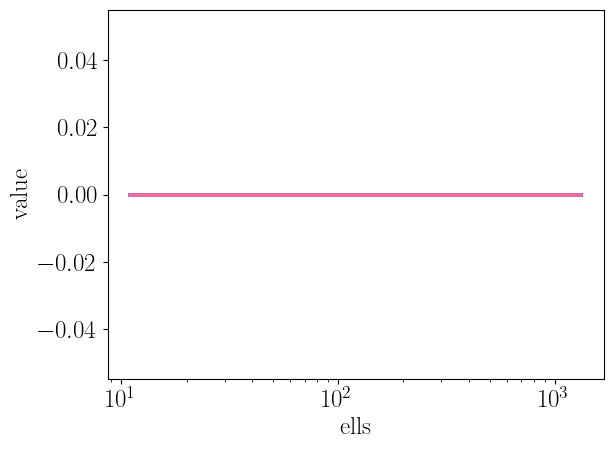

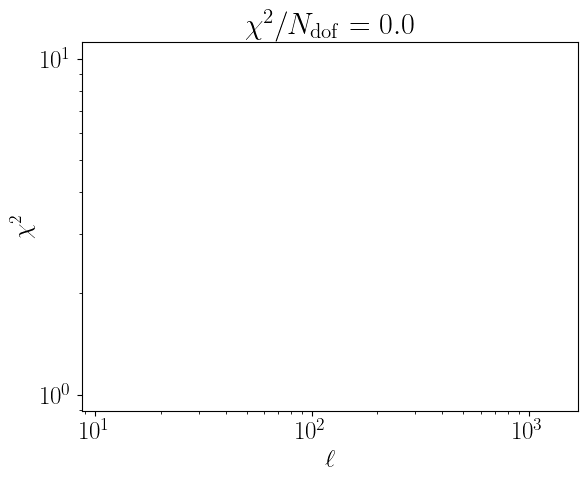

In [16]:
from source_code.compute_obs_sources import get_obs

mytest = get_obs(fiducial,mock.mock_data['distributions'],mock.fiducial_obs['ells'], baseline['likelihood']['LSS']['settings']).Cls

chi2 = []
dof = 0

diff_ell = []
for ind,ell in enumerate(mock.fiducial_obs['ells']):
    diffvec = mytest.iloc[ind][mock.all_cols].values-mock.mock_data['noiseless'].iloc[ind][mock.all_cols].values
    chi2.append(np.dot(diffvec,np.dot(np.linalg.inv(mock.mock_data['covmat_dict'][str(ell)]),diffvec)))#/len(mock.all_cols))
    dof += len(mock.all_cols)
    df = pd.DataFrame({'ells': ell}|{col: mytest.iloc[ind][col]-mock.mock_data['noiseless'].iloc[ind][col]
                                     for col in mock.all_cols},index=[0])
    diff_ell.append(df)

plt.figure()
plot_df = pd.concat(diff_ell,ignore_index=True)
plot_df = pd.melt(plot_df,id_vars=['ells'],value_vars=mock.all_cols,var_name='Bin',value_name='value')
sb.lineplot(plot_df,x='ells',y='value',hue='Bin',legend=0)
plt.xscale('log')

plt.figure()
plt.title(r'$\chi^2/N_{{\rm dof}}={}$'.format(sum(chi2)/dof))
plt.plot(mock.fiducial_obs['ells'],chi2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\chi^2$');

### Manual noisy

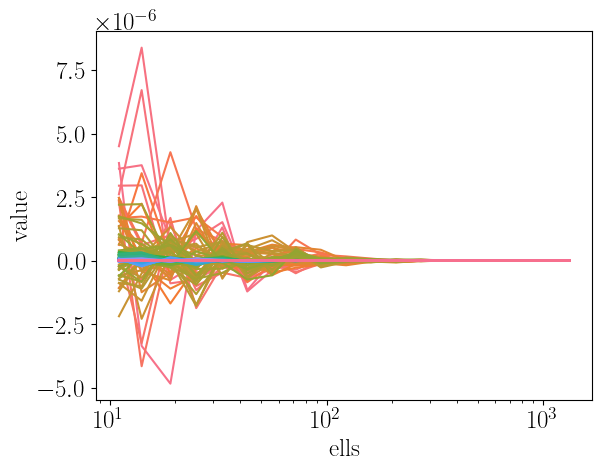

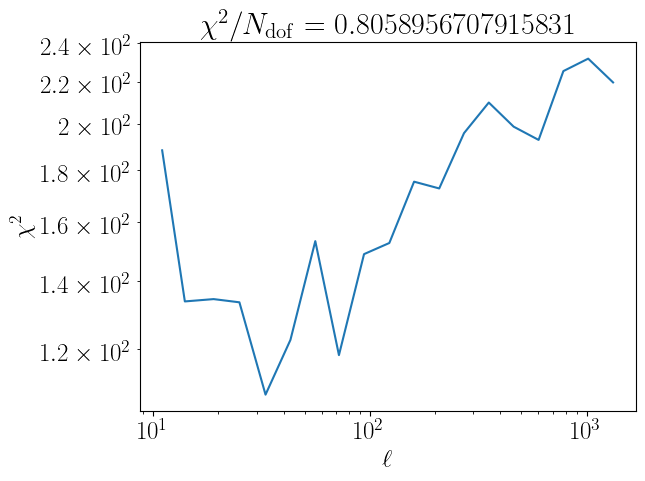

In [17]:
chi2 = []
dof = 0

diff_ell = []
for ind,ell in enumerate(mock.fiducial_obs['ells']):
    diffvec = mytest.iloc[ind][mock.all_cols].values-mock.mock_data['noisy'].iloc[ind][mock.all_cols].values
    chi2.append(np.dot(diffvec,np.dot(np.linalg.inv(mock.mock_data['covmat_dict'][str(ell)]),diffvec)))#/len(mock.all_cols))
    dof += len(mock.all_cols)
    df = pd.DataFrame({'ells': ell}|{col: mock.mock_data['noiseless'].iloc[ind][col]-mock.mock_data['noisy'].iloc[ind][col]
                                     for col in mock.all_cols},index=[0])
    diff_ell.append(df)

plt.figure()
plot_df = pd.concat(diff_ell,ignore_index=True)
plot_df = pd.melt(plot_df,id_vars=['ells'],value_vars=mock.all_cols,var_name='Bin',value_name='value')
sb.lineplot(plot_df,x='ells',y='value',hue='Bin',legend=0)
plt.xscale('log')

plt.figure()
plt.title(r'$\chi^2/N_{{\rm dof}}={}$'.format(sum(chi2)/dof))
plt.plot(mock.fiducial_obs['ells'],chi2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\chi^2$');

### Likelihood noiseless

Covmats inverted in 0.155
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 67
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008
   a2 = -0.004127
   a3 = 0.002918
   a4 = -0.0006784
   b0_poly = 0.830703
   b1_poly = 1.19055
   b2_poly = -0.928357
   b3_poly = 0.423292
[evaluate] Evaluating prior and likelihoods...


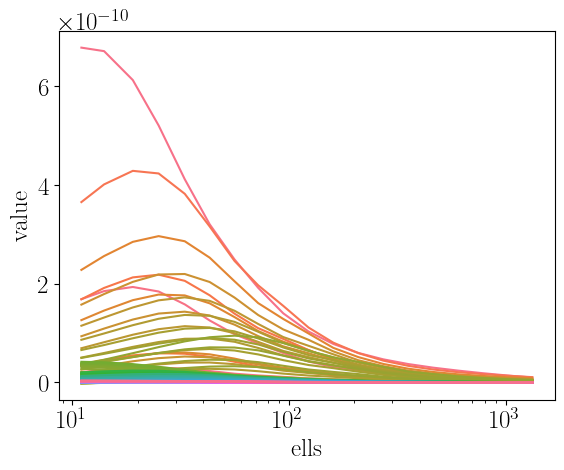

[evaluate] log-posterior  = -2.31403
[evaluate] log-prior      = -2.3115
[evaluate]    logprior_0 = -2.3115
[evaluate] log-likelihood = -0.0025305
[evaluate]    chi2_LSS = 0.00506101
[evaluate] Derived params:
[evaluate]    As = 2.12605e-09
[evaluate]    omegab = 0.05
[evaluate]    omegam = 0.319998


In [18]:
baseline['likelihood']['LSS']['use_noiseless_cls'] = True
updated_info,sampler = run(baseline)

### Likelihood noisy

Covmats inverted in 0.325
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 67
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008
   a2 = -0.004127
   a3 = 0.002918
   a4 = -0.0006784
   b0_poly = 0.830703
   b1_poly = 1.19055
   b2_poly = -0.928357
   b3_poly = 0.423292
[evaluate] Evaluating prior and likelihoods...


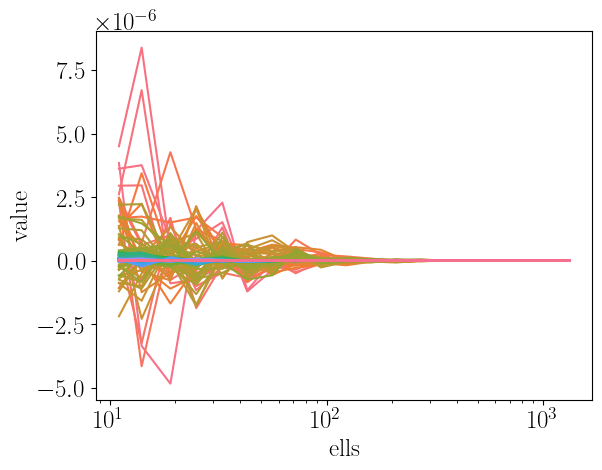

[evaluate] log-posterior  = -1610.12
[evaluate] log-prior      = -2.3115
[evaluate]    logprior_0 = -2.3115
[evaluate] log-likelihood = -1607.81
[evaluate]    chi2_LSS = 3215.61
[evaluate] Derived params:
[evaluate]    As = 2.12605e-09
[evaluate]    omegab = 0.05
[evaluate]    omegam = 0.319998


In [19]:
baseline['likelihood']['LSS']['use_noiseless_cls'] = False
updated_info,sampler = run(baseline)

## Grid $\chi^2$ test

In [20]:
if run_grid_test:
    test_par_vec = np.linspace(mock.fiducial[test_parameter['name']]*(1-test_parameter['variation']),
                               mock.fiducial[test_parameter['name']]*(1+test_parameter['variation']),
                               test_parameter['Ngrid'])
    
    if fiducial[test_parameter['name']] not in test_par_vec:
        test_par_vec = np.append(test_par_vec,fiducial[test_parameter['name']])
    
    baseline['likelihood']['LSS']['use_noiseless_cls'] = test_parameter['noiseless_like']
    
    dfs = []
    
    for val in test_par_vec:
        eval_dict[test_parameter['name']] = val
        baseline['sampler'] = {'evaluate': {'override': eval_dict}}
        updated_info, sampler = run(baseline)
    
        dfs.append(pd.DataFrame({test_parameter['latex']: val,
                                 r'$\chi^2$': -2*sampler.logposterior.loglike},index=[0]))
    
    chi2_df = pd.concat(dfs,ignore_index=True)

In [21]:
if run_grid_test:
    plt.figure()
    sb.lineplot(chi2_df,x=test_parameter['latex'],y=r'$\chi^2$')
    plt.axvline(x=mock.fiducial[test_parameter['name']],ls=':',color='black');